sklearn 의 마지막 모형~

오차를 보완해서 또 하고~~!

연속적

가중치 부여



300-500

500번 해보자 ㅋㅋㅋㅋ

기본 부스팅
-ada > 오답을 보완하는 방향으로 발전
-오차가 이상치에서 나다보이 노이즈에 약함

gbm
- ada 의 확장, 
- 잔차를 보정
- 손실함수 > 성능평가지표 뭐로 쓸거냐
- gbm 의 발전이 xgbost~~ (너무 느리니깡...) > gpu 로 만든게 light gbm > 


배깅 -> 과적합이 된 애를 안되는 방향으로 개선하는 것이지,
즉 일반화성공했으면 배깅이불필요함

베이스모델에서 과적합 다떳다? 배깅해보기....

했는데 예측 성능이 낮다? 그럼 부스팅까지....


그 과정에서 과적합 안뜨던 애도 다시 뜰 수도 있음 (끄럼 포기해,,허허)


cv rmse 가 0.02 보다 작은 즉 과적합 안 뜬애를 기준으로 돌려야해
(과적합 안뜬애의 예측 성능을 끌어 올리는 것)
일반화 조건을 충족하는것 


에러가 일정하게 나야해잉



선형계형도 무조건 거름!!!!!!
이미 규제들이 많아서 최적화가 나름 되어있기 떄문에 부스팅 대상에서 제외!


이 조건 적요하면 의사결정나무밖에 안남음....

ㅋㅋㅋ



~ 은 not


--> 의사결정나무로 채택~ ada, gbm 해보자~


1. ada > 오




# [LAB 08] 지도학습 > 예측 > 앙상블 > 05.Boosting

## #01. 부스팅 (Boosting) 개요
- 여러 개의 약한 모델을 순서대로 학습
- 앞 모델의 실수 오차를 다음 모델이 보완
- 잘못 예측된 데이터에 더 큰 가중치 부여
- 최종적으로 강한 하나의 모델 생성


### [1] 부스팅의 기본 흐름
1. 첫 번째 약한 모델 학습
2. 틀린 데이터의 가중치 증가
3. 다음 모델이 어려운 데이터에 집중
4. 이 과정을 만복
5. 모든 모델 결과를 결합하여 최종 예측



### [2] Adaptive Boosting (AdaBoost)
- 틀린 데이터에 더 집중하는 것
- 가장 기본적인 부스팅 알고리즘
- 틀린 데이터에 가중치를 부여함
- 다음 모델이 해당 데이터에 집중
- 여러 약한 모델을 가중합으로 결합

#### 특징
- 구조가 단순
- 개념 이해 쉬움
- 노이즈에 약함 (틀린 데이터를 찾아내는건데 대부분 이상치이기 떄문에)
  
#### sklearn 지원 모델
- AdaBoostClassifier
- AdaBoostRegressor


### [3] Gradient Boosting (GBM)
- 손실함수를 줄이는 방향으로 보정
- AdaBoost 를 확장한 방식
- 이전 모델의 오차(잔차) 를 줄이도록 학습
- 손실함수의 기울기 사용
- 각 단계에서 이전 모델의 잔차 예측
- 이전 모델이 틀린 만큼을 다음 모델이 맞히도록 학습


#### 특징
- 예측 성능 높음
- 손실함수 선택 가능
- 학습 속도 느림
- 과적합 위험 있음
- 해석 어려움


#### sklearn 지원 모델
- GradientBoostingClassifier
- GradientBoostingRegressor


#### GBM 이후 발전 모델
- GBM 을 개선한 고성능 알고리즘
- 속도,메모리,성능 개선
- XGBOOST, LIGHTGBM,CATBOOST
  


### [4] 앙상블 방식 비교 요약
- Single
  - 하나의 모델, 단순하지만 성능 한계 존재
- Bagging
  - 여러 모델을 병렬로 학습
  - 분산 감소에 효과적
  - 랜덤 포레스트가 대표적인 예시
- Boosting
  - 여러 모델을 순차로 학습
  - 오차를 집중적으로 줄임
  - 성능은 좋지만 느림
  - 정확도 높음, 속도 느림, 과적합 위험 

## #02. 준비 작업
### [1] 패키지 참조

In [9]:
from hossam import *

from pandas import DataFrame
from matplotlib import pyplot as plt
import seaborn as sb
import numpy as np
from itertools import product

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, learning_curve

# 성능평가지표 모듈
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
)

from sklearn.tree import DecisionTreeClassifier,DecisionTreeRegressor

from pandas import merge


#BoostRegressor
from sklearn.ensemble import AdaBoostRegressor,GradientBoostingRegressor

### [2] 성능 평가 함수 정의
- hs_get_scores()
- hs_learning_cv()
- hs_get_score_cv()
- hs_feature_importance()
- hs_shap_analysys()
- hs_shap_dependenve_analysis

### [3] 데이터 가져오기 + 인덱스,타입변환

In [10]:
origin = load_data("restaurant_sales_preprocessed")
origin.set_index("date", inplace=True)
origin["holiday"] = origin["holiday"].astype("category")
origin["weekend"] = origin["weekend"].astype("category")
origin.info()


어느 식당의 1년간 일별 매출을 기록한 데이터의 전처리 완료 버전(명목형이 이진변수만 있으므로 더미변수는 처리하지 않음)
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 353 entries, 2024-01-01 to 2024-12-30
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   sales           353 non-null    float64 
 1   visitors        353 non-null    int64   
 2   avg_price       353 non-null    int64   
 3   marketing_cost  353 non-null    float64 
 4   delivery_ratio  353 non-null    float64 
 5   rain_mm         353 non-null    float64 
 6   temperature     353 non-null    float64 
 7   holiday         353 non-null    category
 8   weekend         353 non-null    category
dtypes: category(2), float64(5), int64(2)
memory usage: 23.0 KB


### [4] 훈련,학습 데이터 분리

In [11]:
df = origin

yname = "sales"
x = df.drop(columns=[yname])
y = df[yname]

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.25, random_state=52
)

x_train.shape, x_test.shape, y_train.shape, y_test.shape

((264, 8), (89, 8), (264,), (89,))

### [5] 베이스 모델에 대한 성능평가 표

In [12]:
score_df = DataFrame(
    [
        ["Linear", 0.709, 0.156, 0.042, 0.204, 0.010, 0.225,
         0.198, 0.203, 0.012, 0.973, 0.060, "⚠️ 판단 유보"],
        
        ["Ridge", 0.708, 0.156, 0.042, 0.205, 0.010, 0.219,
         0.198, 0.203, 0.012, 0.974, 0.058, "⚠️ 판단 유보"],
        
        ["Lasso", 0.707, 0.155, 0.042, 0.205, 0.009, 0.221,
         0.199, 0.204, 0.011, 0.978, 0.055, "⚠️ 판단 유보"],
        
        ["ElasticNet", 0.709, 0.156, 0.042, 0.204, 0.010, 0.223,
         0.198, 0.203, 0.012, 0.974, 0.059, "⚠️ 판단 유보"],
        
        ["SGD", 0.700, 0.160, 0.043, 0.207, 0.010, 0.229,
         0.203, 0.210, 0.019, 0.964, 0.046, "⚠️ 판단 유보"],
        
        ["KNN", 0.635, 0.178, 0.052, 0.229, 0.011, 0.301,
         0.200, 0.220, 0.020, 0.900, 0.090, "⚠️ 과대적합 (variance 큼)"],
        
        ["DecisionTree", 0.620, 0.196, 0.054, 0.233, 0.012, 0.353,
         0.224, 0.245, 0.018, 0.912, 0.072, "✅ 일반화 양호"],
        
        ["SVR", 0.701, 0.157, 0.043, 0.207, 0.010, 0.223,
         0.196, 0.206, 0.011, 0.949, 0.055, "✅ 일반화 양호"],
    ],
    columns=[
        "모델", "결정계수(R2)", "MAE", "MSE", "RMSE", "MAPE", "MPE",
        "Train RMSE", "CV RMSE 평균", "CV RMSE 표준편차",
        "Train/CV 비율", "CV 변동성 비율", "판정 결과",
    ]
)


score_df

,모델,결정계수(R2),MAE,MSE,RMSE,MAPE,MPE,Train RMSE,CV RMSE 평균,CV RMSE 표준편차,Train/CV 비율,CV 변동성 비율,판정 결과
0,Linear,0.709,0.156,0.042,0.204,0.010,0.225,0.198,0.203,0.012,0.973,0.060,⚠️ 판단 유보
1,Ridge,0.708,0.156,0.042,0.205,0.010,0.219,0.198,0.203,0.012,0.974,0.058,⚠️ 판단 유보
2,Lasso,0.707,0.155,0.042,0.205,0.009,0.221,0.199,0.204,0.011,0.978,0.055,⚠️ 판단 유보
3,ElasticNet,0.709,0.156,0.042,0.204,0.010,0.223,0.198,0.203,0.012,0.974,0.059,⚠️ 판단 유보
4,SGD,0.700,0.160,0.043,0.207,0.010,0.229,0.203,0.210,0.019,0.964,0.046,⚠️ 판단 유보
5,KNN,0.635,0.178,0.052,0.229,0.011,0.301,0.200,0.220,0.020,0.900,0.090,⚠️ 과대적합 (variance 큼)
6,DecisionTree,0.620,0.196,0.054,0.233,0.012,0.353,0.224,0.245,0.018,0.912,0.072,✅ 일반화 양호
7,SVR,0.701,0.157,0.043,0.207,0.010,0.223,0.196,0.206,0.011,0.949,0.055,✅ 일반화 양호


## #03. Boosting 후보 선정 기준


부스팅은 너무 불안하지도 않고, 이미 완성도가 높은 모델이 아닌
아직 덜 안성되었지만 안정적인 모델에 적합


### [1] Boosting 후보의 기본 조건
- 교차검증 성능의 변동성이 일정 수준 이하일 것 
  - CV RMSE 표준편차 <= 0.02
  - 즉, 데이터가 변경되었을 때 성능이 너무 달라지는 모델에는 부적합
  - 부스팅은 모델을 만들면 그 결과를 다음 모델이 이어받는 구조이기 떄문에, 첫 모델이 흔들리면 그 뒤 모델들은 모두 틀린 방향으로 계속 보정하게 된다
  
- 학습 성능과 교차 검증 성능의 괴리가 과도하지 않을 것
  - 0.85 <= Train/CV 비율 <= 1.05
  - train 성능과 cv 성능 (cross validation) 즉, 모델이 학습한 데이터와 학습하지 않았던 데이터에서 나오는 성능이 너무 다르면 안된다.
  - 조금씩 수정해나가야하기 때문에 기본적으로 균현 잡힌 모델이 필요함


- 교차 검증 평균 성능이 비교 가능한 수준일 것
  - CV RMSE 평균을 정렬 기준으로 활용
  - 즉, 여러번 테스트를 봐서 평균 점수로 모델을 비교한다
  - RMSE 는 예측값과 실제값의 오차 크기로 작을 수록 좋은 값이고, CV 는 교차 검증 -> CV RMSE 는 모델의 실전 평균 오차
  - 즉, 한번 잘한 모델이 아니라 평균적으로 잘한 모델을 고른다는 뜻
  - 성능이 너무 안좋은 모델은 부스팅을 해도 도움이 안된다



### [2] 1차 제외 대상 :교차대상 불안정 모델 
다음 조건에 해당하는 모델은 Boosting 후보에서 제외됨.

- 교차검증 성능의 분산이 큰 경우
 - CV RMSE 표준편차 > 0.02

해당 조건은 Boosting이 순차 학습 구조를 가지므로
변동성이 큰 모델을 사용할 경우 오차 증폭 가능성이 커지기 때문임.



### [3] 2차 제외 대상 : Train CV 괴리 모델
다음 조건을 만족하지 못하는 모델은 제외됨.

- Train/CV 비율 < 0.85 : 과소적합 가능성 (너무 단순한 모형)
- Train/CV 비율 > 1.05 : 과대적합 가능성 (너무 많이 학습된 모형)

이는 Boosting 적용 이전 단계에서
기본적인 일반화 안정성 확보 여부를 판단하기 위한 조건임.


### [4] 선형 계열 모델 제외
코드에서는 다음 모델들을 명시적으로 Boosting 후보에서 제외함.

- Linear
- Ridge
- Lasso
- ElasticNet
- SGD

이는 모델 성능이 나쁘기 때문이 아니라,

이미 규제 및 최적화로 bias–variance 균형이 비교적 안정적으로 형성되어 있고
Boosting 적용 시 성능 개선 여지가 상대적으로 작기 때문임.



### [5] Boosting 우선순위 정렬 기준

최종 후보군은 다음 기준으로 정렬됨.

- 결정계수(R²) 오름차순 (R² 가 낮은 모델부터 확인)
 - 단일 모델 성능이 낮을수록 개선 여지가 큼

- CV RMSE 평균 오름차순
 - 기본적인 일반화 성능 확보 여부를 반영
 - 결정계수는 낮아도, 안정적인 모델

In [13]:
MAX_CV_VARIABILITY = 0.02      # CV 변동성 상한
MIN_TRAIN_CV_RATIO = 0.85     # Train/CV 비율 하한
MAX_TRAIN_CV_RATIO = 1.05     # Train/CV 비율 상한

LINEAR_MODELS = [
    "Linear",
    "Ridge",
    "Lasso",
    "ElasticNet",
    "SGD",
]

boosting_df = score_df.copy()


# (1) 교차검증 변동성 과도한 모델 제거
boosting_df = boosting_df[
    boosting_df["CV RMSE 표준편차"] <= MAX_CV_VARIABILITY
]

# (2) Train / CV 괴리 큰 모델 제거
boosting_df = boosting_df[
    (boosting_df["Train/CV 비율"] >= MIN_TRAIN_CV_RATIO) &
    (boosting_df["Train/CV 비율"] <= MAX_TRAIN_CV_RATIO)
]

# Boosting은 단일 성능이 낮을수록 개선 여지가 큼
# → R2가 낮은 모델에 가중치 부여
boosting_df = boosting_df.sort_values(
    by=["결정계수(R2)", "CV RMSE 평균"],
    ascending=[True, True]
)

# 선형 계열 제거
boosting_df = boosting_df[
    ~boosting_df["모델"].isin(LINEAR_MODELS)
]
# 최종 후보 출력
boosting_candidates = boosting_df[
    ["모델", "결정계수(R2)", "CV RMSE 평균", "Train/CV 비율", "CV RMSE 표준편차"]
]

boosting_candidates.reset_index(drop=True, inplace=True)
boosting_candidates


,모델,결정계수(R2),CV RMSE 평균,Train/CV 비율,CV RMSE 표준편차
0,DecisionTree,0.620,0.245,0.912,0.018
1,KNN,0.635,0.220,0.900,0.020
2,SVR,0.701,0.206,0.949,0.011


### [6] 최종 후보 (Decision Tree)

In [14]:
%%time

dt = DecisionTreeRegressor(random_state=52)

# 하이퍼파라미터 그리드
param_grid = {
    "max_depth": [3, 5, 7, 10, None],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 5, 10, 20],
    "max_features": [None, "sqrt", "log2"],
    "criterion": ["squared_error", "absolute_error"],
    "max_leaf_nodes": [None, 10, 20, 30, 50],
    "min_impurity_decrease": [0.0, 0.01, 0.1],
}

# GridSearchCV
gs = GridSearchCV(
    estimator=dt,
    param_grid=param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)
# 학습
gs.fit(x_train, y_train)

# 최적 모델
best_model = gs.best_estimator_


CPU times: total: 5.47 s
Wall time: 17.2 s


## #04. AdaBoosting
### [1] 주요 하이퍼 파라미터

| 파라미터명 | 핵심도 | 설명 | 기본값 | GridSearchCV 권장값 |
|-----------|-------|------|--------|-------------------|
| n_estimators | ⭐⭐⭐ | 약한 모델(트리) 개수<br>Bias(편향) 감소에 직접적 영향 | 50 | [50, 100, 200, 300] |
| learning_rate | ⭐⭐⭐ | 각 트리의 기여도 조절 계수<br>작을수록 안정, 클수록 학습 빠름 | 1.0 | [0.01, 0.05, 0.1, 0.3, 1.0] |
| estimator | ⭐⭐⭐ | 기본 약한 학습기<br>보통 얕은 결정트리 사용 | None | best_model |
| loss | ⭐⭐ | 오차 반영 방식 (회귀 전용)<br>이상치 민감도 차이 | 'linear' | ['linear', 'square', 'exponential'] |
| random_state | ✅ | 재현성 확보 시드 | None | 52 |



1. n_estimators : 모델을 만들어서 틀린 데이터에 집중해서 다시 반드는 과정을 몇 번 반복할지 
2. learning_rate:

CPU times: total: 641 ms
Wall time: 7.23 s


,결정계수(R2),평균절대오차(MAE),평균제곱오차(MSE),평균오차(RMSE),평균 절대 백분오차 비율(MAPE),평균 비율 오차(MPE),Train RMSE,CV RMSE 평균,CV RMSE 표준편차,Train/CV 비율,CV 변동성 비율,판정 결과
AdaBoostRegressor,0.773,0.151,0.033,0.182,0.009,-0.063,0.183,0.221,0.016,0.827,0.074,✅ 일반화 양호


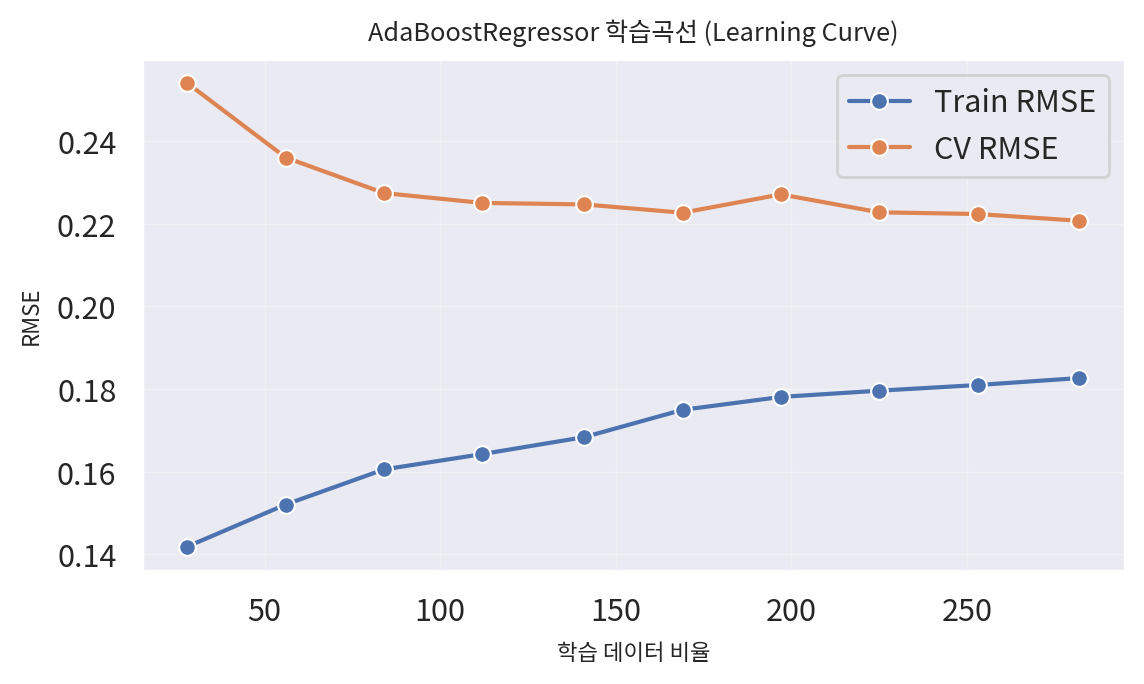

In [15]:
%%time

ada = AdaBoostRegressor(
    estimator=best_model,   # 이미 GridSearch로 튜닝된 트리
    random_state=52
)

param_grid = {
    "n_estimators": [50, 100, 200, 300],
    "learning_rate": [0.01, 0.05, 0.1, 0.3, 1.0],
    "loss": ["linear", "square", "exponential"],
}

gs_ada = GridSearchCV(
    estimator=ada,
    param_grid=param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)


gs_ada.fit(x_train, y_train)

best_ada_model = gs_ada.best_estimator_

hs_get_score_cv(best_ada_model, x_train, y_train, x, y)



## #05. Gradient Boosting

| 파라미터명 | 핵심도 | 설명 | 기본값 | GridSearchCV 권장값 |
|-----------|-------|------|--------|-------------------|
| n_estimators | ⭐⭐⭐ | 부스팅 반복 횟수(트리 개수)<br>Bias 감소에 직접적 영향 | 100 | [100, 200, 300, 500] |
| learning_rate | ⭐⭐⭐ | 각 트리의 기여도 조절 계수<br>작을수록 안정, 클수록 과적합 위험 | 0.1 | [0.01, 0.05, 0.1, 0.2] |
| max_depth | ⭐⭐⭐ | 개별 트리 깊이 제한<br>Variance 직접 제어 | 3 | [2, 3, 5, 7] |
| min_samples_split | ⭐⭐ | 노드 분할 최소 샘플 수 | 2 | [2, 5, 10, 20] |
| min_samples_leaf | ⭐⭐ | 리프 노드 최소 샘플 수 | 1 | [1, 5, 10, 20] |
| subsample | ⭐⭐⭐ | 각 트리 학습에 사용하는 샘플 비율<br>1보다 작으면 Stochastic GBM | 1.0 | [0.6, 0.8, 1.0] |
| max_features | ⭐⭐ | 분할 시 고려할 변수 수 | None | [None, 'sqrt', 'log2'] |
| loss | ⭐⭐ | 손실 함수 (회귀 기준) | 'squared_error' | ['squared_error', 'absolute_error', 'huber'] |
| alpha | ⭐ | Huber / Quantile 손실의 분위수 파라미터 | 0.9 | [0.85, 0.9, 0.95] |
| random_state | ✅ | 재현성 확보 시드 | None | 52 |


- 트리 개수(n_estimators)와 학습률(learning_rate)은 함께 조정

- 과적합 징후 시
  - max_depth ↓
  - subsample ↓
  - min_samples_leaf ↑

- 계산량 부담 큰 경우
  - n_estimators 상한 축소
  - loss를 'squared_error'로 고정


CPU times: total: 45.4 s
Wall time: 10min 43s


,결정계수(R2),평균절대오차(MAE),평균제곱오차(MSE),평균오차(RMSE),평균 절대 백분오차 비율(MAPE),평균 비율 오차(MPE),Train RMSE,CV RMSE 평균,CV RMSE 표준편차,Train/CV 비율,CV 변동성 비율,판정 결과
GradientBoostingRegressor,0.828,0.125,0.025,0.159,0.008,-0.001,0.160,0.215,0.012,0.743,0.054,⚠️ 과대적합 (variance 큼)


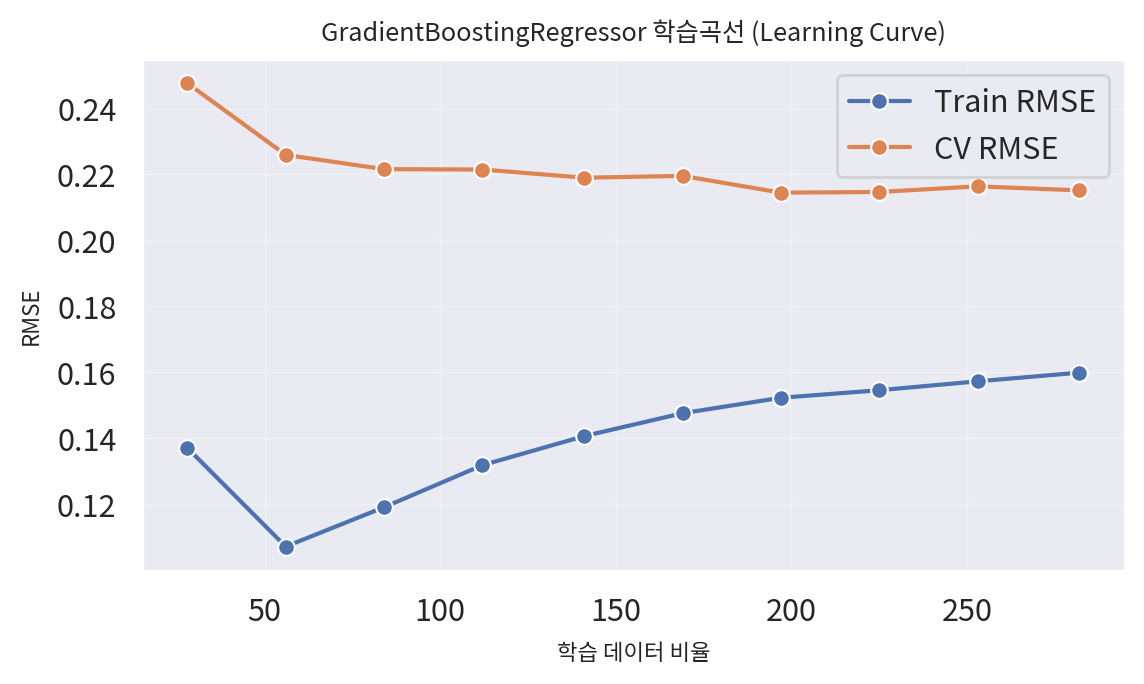

In [16]:
%%time

gbr = GradientBoostingRegressor(
    random_state=52
)

param_grid = {
    "n_estimators": [100, 200, 300,500],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "max_depth": [2, 3, 5, 7],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 5, 10, 20],
    "subsample": [0.6, 0.8, 1.0],
    "max_features": [None, "sqrt", "log2"],
    "loss": ["squared_error"],
}

gs_gbr = GridSearchCV(
    estimator=gbr,
    param_grid=param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)


gs_gbr.fit(x_train, y_train)

best_gbr_model = gs_gbr.best_estimator_

hs_get_score_cv(best_gbr_model, x_train, y_train, x, y)
